In [1054]:
from scipy import stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1055]:
def generate_synthetic_data_flexible_purchase_prob(
    num_individuals=150,
    num_dates=50,
    purchase_prob_treatment=0.18,
    purchase_prob_control=0.12,
    skewed_revenue=False,
    seed = 21
):
    """
    Generates a synthetic dataset for A/B testing, including individual IDs,
    dates, treatment assignment, purchase indicators, and realized revenue.

    The function allows for setting different purchase probabilities for
    treatment and control groups, and offers options for revenue distribution.

    Args:
        num_individuals (int): The total number of unique individuals in the dataset.
                               Defaults to 1000.
        num_dates (int): The number of days for which to generate data.
                         Defaults to 30.
        purchase_prob_treatment (float): The probability of an individual in the
                                         'treatment' group making a purchase on any given day.
                                         Must be between 0 and 1. Defaults to 0.18.
        purchase_prob_control (float): The probability of an individual in the
                                        'control' group making a purchase on any given day.
                                        Must be between 0 and 1. Defaults to 0.12.
        skewed_revenue (bool): If True, generates revenue from a highly skewed
                               (lognormal with specific parameters for more extreme skew)
                               distribution when a purchase is made. If False, generates
                               revenue from a less skewed (lognormal with different parameters)
                               distribution. Defaults to False.
        seed (int): The seed for NumPy's random number generator to ensure
                    reproducibility of the generated data. Defaults to 21.

    Returns:
        pandas.DataFrame: A DataFrame with the following columns:
            - 'date' (datetime): The date of the observation.
            - 'individual_id' (str): Unique identifier for each individual.
            - 'treatment' (str): 'treatment' or 'control', indicating group assignment.
            - 'made_purchase' (int): 1 if a purchase was made, 0 otherwise.
            - 'revenue' (float): The realized revenue; 0 if no purchase was made.
    """
    np.random.seed(seed)
    dates = pd.to_datetime(['2025-01-01'] + [pd.Timestamp('2025-01-01') + pd.Timedelta(days=i) for i in range(1, num_dates)])
    individual_ids = [f'ID_{i+1:04d}' for i in range(num_individuals)]
    treatment_assignment = np.random.choice(['treatment', 'control'], size=num_individuals)

    data = []
    for date in dates:
        for i in range(num_individuals):
            treatment = treatment_assignment[i]
            if treatment == 'treatment':
                purchase_prob = purchase_prob_treatment
            else:
                purchase_prob = purchase_prob_control

            made_purchase = np.random.binomial(1, purchase_prob)

            if made_purchase:
                if skewed_revenue:
                    # Highly skewed revenue (lognormal with larger sigma for more extreme values)
                    revenue = np.random.lognormal(mean=0.5, sigma=1.0) * 2
                else:
                    # Less skewed, more 'normal-like' revenue (lognormal with smaller sigma)
                    revenue = np.random.lognormal(mean=2, sigma=0.3)
            else:
                revenue = 0.0
            data.append({
                'date': date,
                'individual_id': individual_ids[i],
                'treatment': treatment,
                'made_purchase': made_purchase,
                'revenue': revenue
            })

    return pd.DataFrame(data)

In [1056]:
# Generate the synthetic dataset with different purchase probabilities
synthetic_df = generate_synthetic_data_flexible_purchase_prob(
    num_individuals=150,
    num_dates=50,
    purchase_prob_treatment=0.11,
    purchase_prob_control=0.10,
    skewed_revenue=False,
    seed=1
)

synthetic_df2 = generate_synthetic_data_flexible_purchase_prob(
    purchase_prob_treatment=0.45,
    purchase_prob_control=0.43,
    skewed_revenue=True,
    seed=1
)

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
/var/folders/x3/z5cc46r95bz2yf3v104lyh8h0000gn/T/ipykernel_52282/4140200863.py:6: SyntaxWarning: invalid escape sequence '\s'
  axes[0].set_title('Revenue Distribution ($\sigma=0.3$)')
/var/folders/x3/z5cc46r95bz2yf3v104lyh8h0000gn/T/ipykernel_52282/4140200863.py:12: SyntaxWarning: invalid escape sequence '\s'
  axes[1].set_title('Revenue Distribution (($\sigma=2$))')


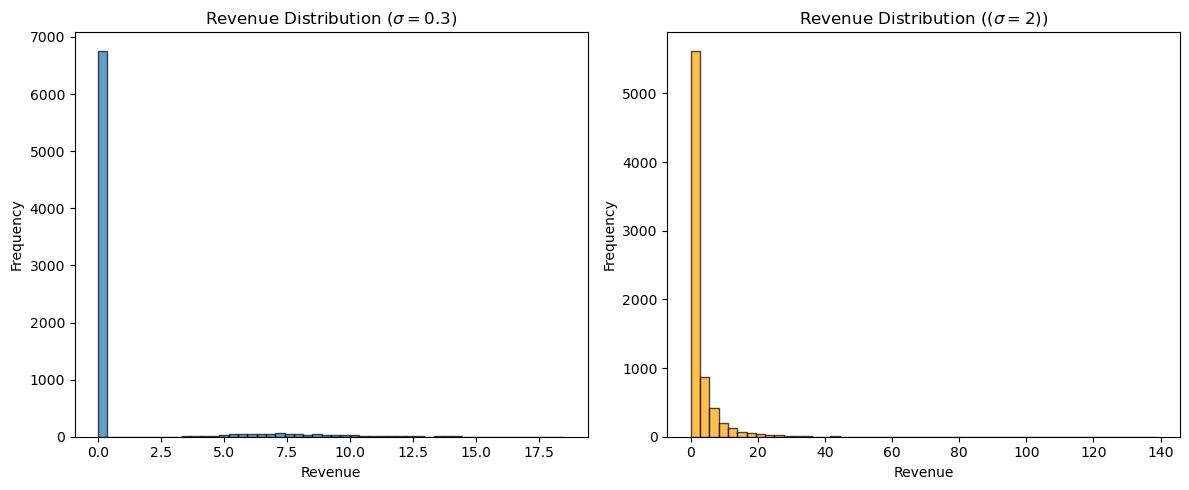

In [1057]:
# Create subplots for side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot histogram for synthetic_df
axes[0].hist(synthetic_df['revenue'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Revenue Distribution ($\sigma=0.3$)')
axes[0].set_xlabel('Revenue')
axes[0].set_ylabel('Frequency')

# Plot histogram for synthetic_df2
axes[1].hist(synthetic_df2['revenue'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Revenue Distribution (($\sigma=2$))')
axes[1].set_xlabel('Revenue')
axes[1].set_ylabel('Frequency')

plt.tight_layout()

In [1058]:
def get_confidence_interval(
    row: pd.Series,
    target_var: str,
    full_df: pd.DataFrame,
    confidence_level: float = 0.95
) -> pd.Series:
    """
    Calculates the confidence interval for the difference between treatment
    and control groups for a given date, based on the type of target variable.

    This function is designed to be applied row-wise to a DataFrame that
    contains 'date' and 'difference' columns (e.g., `daily_purchase_rates`).
    It then re-queries the `full_df` to get the underlying data for the
    specified date and treatment groups to calculate the confidence interval.

    Args:
        row: A pandas Series representing a row from the aggregated DataFrame
             (e.g., `daily_purchase_rates`). It is expected to contain at
             least 'date' and 'difference' columns.
        target_var: The name of the column in `full_df` that represents the
                    dependent variable (e.g., 'made_purchase', 'value_per_purchase').
        full_df: The complete, unaggregated pandas DataFrame containing the
                 raw data with 'date', 'treatment', and `target_var` columns.
        confidence_level: The confidence level for the interval (e.g., 0.95 for 95% CI).

    Returns:
        A pandas Series with two elements: 'lower_ci' and 'upper_ci',
        representing the lower and upper bounds of the confidence interval.
        Returns NaN for both if data is insufficient for calculation.
    """
    current_date = row['date']
    observed_difference = row['difference']

    # Filter data for the current date
    daily_data = full_df[full_df['date'] == current_date]

    # Extract data for treatment and control groups
    treatment_data = daily_data[daily_data['treatment'] == 'treatment'][target_var]
    control_data = daily_data[daily_data['treatment'] == 'control'][target_var]

    n_treatment = treatment_data.count() # Use .count() to exclude NaNs
    n_control = control_data.count()

    # Determine if the target variable is binary (e.g., 0/1, True/False)
    # This check is performed on the full_df to get a general understanding of the column type
    is_target_binary = full_df[target_var].nunique(dropna=True) == 2

    if is_target_binary:
        # Confidence interval for difference in proportions (e.g., purchase rate)
        success_treatment = treatment_data.sum()
        success_control = control_data.sum()

        if n_treatment > 0 and n_control > 0:
            # Pooled proportion for standard error calculation (for hypothesis testing of difference)
            pooled_proportion = (success_treatment + success_control) / (n_treatment + n_control)
            
            # Ensure pooled_proportion is within [0, 1] bounds for sqrt
            pooled_proportion = np.clip(pooled_proportion, 0, 1)

            # Standard error of the difference in proportions
            standard_error_diff = np.sqrt(pooled_proportion * (1 - pooled_proportion) * (1 / n_treatment + 1 / n_control))
            
            # Z-score for the given confidence level (two-tailed)
            z_score = stats.norm.ppf(1 - (1 - confidence_level) / 2)
            margin_of_error = z_score * standard_error_diff
            
            lower_bound = observed_difference - margin_of_error
            upper_bound = observed_difference + margin_of_error
            return pd.Series({'lower_ci': lower_bound, 'upper_ci': upper_bound})
        else:
            return pd.Series({'lower_ci': np.nan, 'upper_ci': np.nan})
    else:
        # Confidence interval for difference in means (e.g., average value)
        if n_treatment > 1 and n_control > 1: # Need at least 2 samples for std dev
            # Standard error of the difference in means (Welch's t-test approximation)
            std_err_diff = np.sqrt(treatment_data.std(ddof=1)**2 / n_treatment +
                                    control_data.std(ddof=1)**2 / n_control)
            
            # Degrees of freedom for Welch's t-test (Satterthwaite approximation)
            # A more precise calculation for degrees of freedom for Welch's t-test
            # is complex. A conservative estimate is min(n1, n2) - 1, or n1 + n2 - 2
            # for pooled variance, but here we use Welch's for unequal variances.
            # For simplicity, using a conservative estimate or a more common approximation:
            # If std_err_diff is 0, this will cause issues, handle that case.
            if std_err_diff == 0:
                degrees_freedom = n_treatment + n_control - 2
            else:
                numerator = (treatment_data.std(ddof=1)**2 / n_treatment + control_data.std(ddof=1)**2 / n_control)**2
                denominator = (treatment_data.std(ddof=1)**2 / n_treatment)**2 / (n_treatment - 1) + \
                              (control_data.std(ddof=1)**2 / n_control)**2 / (n_control - 1)
                degrees_freedom = numerator / denominator if denominator > 0 else n_treatment + n_control - 2
            
            # Ensure degrees of freedom is at least 1
            degrees_freedom = max(1, degrees_freedom)

            # T-score for the given confidence level (two-tailed)
            t_score = stats.t.ppf(1 - (1 - confidence_level) / 2, df=degrees_freedom)
            margin_of_error = t_score * std_err_diff
            
            lower_ci = observed_difference - margin_of_error
            upper_ci = observed_difference + margin_of_error
            return pd.Series({'lower_ci': lower_ci, 'upper_ci': upper_ci})
        else:
            return pd.Series({'lower_ci': np.nan, 'upper_ci': np.nan})


def daily_plot(
    df: pd.DataFrame,
    target_var: str,
    target_name: str,
    confidence_level: float = 0.95
) -> None:
    """
    Generates and displays a time-series plot of the daily difference between
    treatment and control groups for a specified target variable, including
    a confidence interval.

    Args:
        df: The input pandas DataFrame containing 'date', 'treatment', and
            `target_var` columns.
        target_var: The name of the column in `df` representing the dependent
                    variable (e.g., 'made_purchase', 'value_per_purchase').
        target_name: A user-friendly name for the target variable, used in plot labels
                     and titles (e.g., 'Purchase Rate', 'Average Order Value').
        confidence_level: The confidence level for the confidence interval (e.g., 0.95).

    Returns:
        None. Displays a matplotlib plot.
    """
    # Calculate daily means for treatment and control groups
    daily_aggregated = df.groupby(['date', 'treatment'])[target_var].mean().unstack()
    
    # Calculate the difference between treatment and control means
    daily_aggregated['difference'] = daily_aggregated['treatment'] - daily_aggregated['control']
    
    # Reset index to make 'date' a regular column for plotting and apply
    daily_aggregated = daily_aggregated.reset_index()

    # Calculate confidence intervals for each daily difference
    daily_aggregated[['lower_ci', 'upper_ci']] = daily_aggregated.apply(
        lambda row: get_confidence_interval(
            row,
            target_var,
            full_df=df, # Pass the original DataFrame here
            confidence_level=confidence_level
        ),
        axis=1,
        result_type='expand'
    )
    
    # Plot the difference with confidence intervals
    plt.figure(figsize=(12, 6))
    plt.plot(
        daily_aggregated['date'],
        daily_aggregated['difference'],
        marker='o',
        linestyle='-',
        label=f'Difference in {target_name} (Treatment - Control)'
    )
    plt.fill_between(
        daily_aggregated['date'],
        daily_aggregated['lower_ci'],
        daily_aggregated['upper_ci'],
        alpha=0.2,
        color='blue',
        label=f'{int(confidence_level*100)}% Confidence Interval'
    )
    
    # Add a horizontal line at zero
    plt.axhline(y=0, color='red', linestyle='--', label='Zero Difference')
    
    # Add labels and title
    plt.xlabel('Date')
    plt.ylabel(f'Difference in {target_name}')
    plt.title(f'Daily Difference in {target_name} (Treatment vs. Control) Over Time with {int(confidence_level*100)}% CI')
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


def cumulative_plot(
    df: pd.DataFrame,
    target_var: str,
    target_name: str,
    confidence_level: float = 0.95
) -> None:
    """
    Generates and displays a time-series plot of the cumulative difference
    between treatment and control groups for a specified target variable,
    including a confidence interval.

    This function calculates cumulative statistics up to each unique date
    and then computes the difference and its confidence interval.

    Args:
        df: The input pandas DataFrame containing 'date', 'treatment', and
            `target_var` columns.
        target_var: The name of the column in `df` representing the dependent
                    variable (e.g., 'made_purchase', 'value_per_purchase').
        target_name: A user-friendly name for the target variable, used in plot labels
                     and titles (e.g., 'Purchase Rate', 'Average Order Value').
        confidence_level: The confidence level for the confidence interval (e.g., 0.95).

    Returns:
        None. Displays a matplotlib plot.
    """
    # Sort the DataFrame by date to ensure correct cumulative calculation
    sorted_df = df.sort_values('date')

    cumulative_results = []
    unique_dates = sorted_df['date'].unique()
    
    # Determine if the target variable is binary once
    is_target_binary = sorted_df[target_var].nunique(dropna=True) == 2
    
    # Z-score or T-score for the given confidence level (two-tailed)
    alpha = 1 - confidence_level
    z_score = stats.norm.ppf(1 - alpha / 2) # For proportions
    
    for current_date in unique_dates:
        # Get all data up to the current date
        cumulative_data = sorted_df[sorted_df['date'] <= current_date]
        
        treatment_target_series = cumulative_data[cumulative_data['treatment'] == 'treatment'][target_var]
        control_target_series = cumulative_data[cumulative_data['treatment'] == 'control'][target_var]
        
        n_treatment = treatment_target_series.count()
        n_control = control_target_series.count()
        
        difference = np.nan
        lower_ci = np.nan
        upper_ci = np.nan

        if is_target_binary:
            # Cumulative confidence interval for difference in proportions
            success_treatment = treatment_target_series.sum()
            rate_treatment = success_treatment / n_treatment if n_treatment > 0 else np.nan
            
            success_control = control_target_series.sum()
            rate_control = success_control / n_control if n_control > 0 else np.nan
            
            difference = rate_treatment - rate_control
            
            if n_treatment > 0 and n_control > 0:
                pooled_proportion = (success_treatment + success_control) / (n_treatment + n_control)
                pooled_proportion = np.clip(pooled_proportion, 0, 1) # Ensure bounds
                
                standard_error_diff = np.sqrt(pooled_proportion * (1 - pooled_proportion) * (1 / n_treatment + 1 / n_control))
                
                margin_of_error = z_score * standard_error_diff
                lower_ci = difference - margin_of_error
                upper_ci = difference + margin_of_error
        else:
            # Cumulative confidence interval for difference in means
            mean_target_treatment = treatment_target_series.mean() if n_treatment > 0 else np.nan
            mean_target_control = control_target_series.mean() if n_control > 0 else np.nan
            
            difference = mean_target_treatment - mean_target_control
            
            if n_treatment > 1 and n_control > 1:
                std_err_diff = np.sqrt(treatment_target_series.std(ddof=1)**2 / n_treatment +
                                        control_target_series.std(ddof=1)**2 / n_control)
                
                # Degrees of freedom for Welch's t-test (Satterthwaite approximation)
                if std_err_diff == 0:
                    degrees_freedom = n_treatment + n_control - 2
                else:
                    numerator = (treatment_target_series.std(ddof=1)**2 / n_treatment + control_target_series.std(ddof=1)**2 / n_control)**2
                    denominator = (treatment_target_series.std(ddof=1)**2 / n_treatment)**2 / (n_treatment - 1) + \
                                  (control_target_series.std(ddof=1)**2 / n_control)**2 / (n_control - 1)
                    degrees_freedom = numerator / denominator if denominator > 0 else n_treatment + n_control - 2
                
                degrees_freedom = max(1, degrees_freedom) # Ensure at least 1
                
                t_score = stats.t.ppf(1 - alpha / 2, df=degrees_freedom)
                margin_of_error = t_score * std_err_diff
                
                lower_ci = difference - margin_of_error
                upper_ci = difference + margin_of_error
        
        cumulative_results.append({
            'date': current_date,
            'difference': difference,
            'lower_ci': lower_ci,
            'upper_ci': upper_ci
        })
            
    cumulative_df = pd.DataFrame(cumulative_results)
    
    # Plot the cumulative difference with confidence intervals
    plt.figure(figsize=(12, 6))
    plt.plot(
        cumulative_df['date'],
        cumulative_df['difference'],
        marker='o',
        linestyle='-',
        label=f'Cumulative Difference in {target_name} (Treatment - Control)'
    )
    plt.fill_between(
        cumulative_df['date'],
        cumulative_df['lower_ci'],
        cumulative_df['upper_ci'],
        alpha=0.2,
        color='blue',
        label=f'{int(confidence_level*100)}% Confidence Interval'
    )
    
    # Add a horizontal line at zero
    plt.axhline(y=0, color='red', linestyle='--', label='Zero Difference')
    
    # Add labels and title
    plt.xlabel('Date')
    plt.ylabel(f'Cumulative Difference in {target_name}')
    plt.title(f'Cumulative Difference in {target_name} (Treatment vs. Control) Over Time with {int(confidence_level*100)}% CI')
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

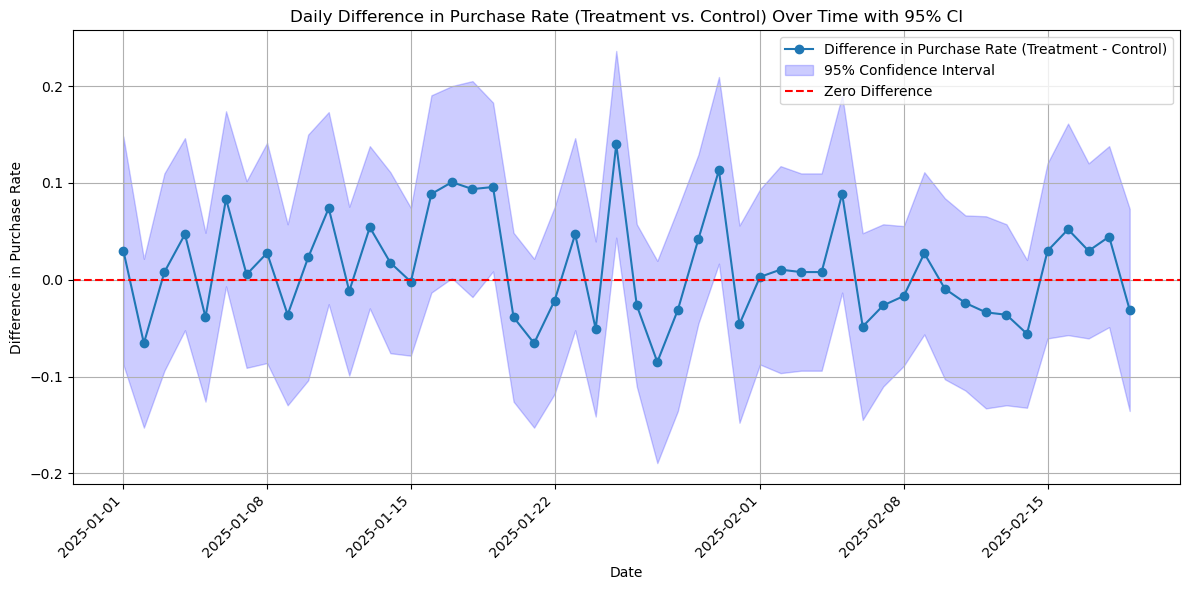

In [1059]:
daily_plot(synthetic_df, 'made_purchase', 'Purchase Rate')

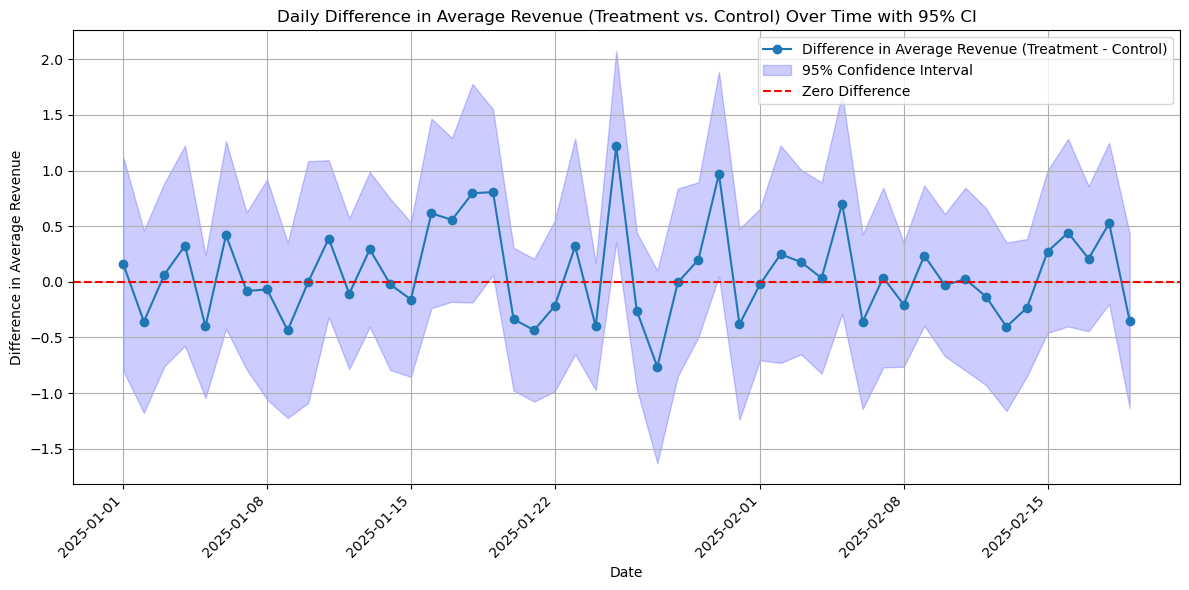

In [1060]:
daily_plot(synthetic_df, 'revenue', 'Average Revenue')

In [1061]:
def plot_revenue_distributions(df: pd.DataFrame):
    """
    Generates two side-by-side plots of revenue distribution by treatment group:
    1. Overall revenue distribution (including zero revenue).
    2. Revenue distribution for non-zero purchases only.

    Args:
        df (pandas.DataFrame): The dataset containing 'treatment' and 'revenue' columns.
    """
    # Separate data by treatment group for the first plot (all revenue)
    treatment_all_revenue = df[df['treatment'] == 'treatment']['revenue']
    control_all_revenue = df[df['treatment'] == 'control']['revenue']

    # Filter for non-zero revenue for the second plot
    df_non_zero_revenue = df[df['revenue'] > 0]
    treatment_non_zero_revenue = df_non_zero_revenue[df_non_zero_revenue['treatment'] == 'treatment']['revenue']
    control_non_zero_revenue = df_non_zero_revenue[df_non_zero_revenue['treatment'] == 'control']['revenue']

    # Create a figure with two subplots (1 row, 2 columns)
    fig, axes = plt.subplots(1, 2, figsize=(18, 7)) # Increased width for two plots

    # --- Plot 1: Overall Revenue Distribution ---
    sns.histplot(treatment_all_revenue, label='Treatment', kde=True, ax=axes[0], color='blue')
    sns.histplot(control_all_revenue, label='Control', kde=True, ax=axes[0], color='orange')

    axes[0].set_xlabel('Revenue')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Overall Revenue Distribution by Treatment Group')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # --- Plot 2: Non-Zero Revenue Distribution ---
    # It's often useful to use a log scale for highly skewed revenue distributions
    # especially when focusing on non-zero values. Uncomment if desired.
    # axes[1].set_xscale('log')

    sns.histplot(treatment_non_zero_revenue, label='Treatment', kde=True, ax=axes[1], color='blue')
    sns.histplot(control_non_zero_revenue, label='Control', kde=True, ax=axes[1], color='orange')

    axes[1].set_xlabel('Revenue (Non-Zero)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Non-Zero Revenue Distribution by Treatment Group')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

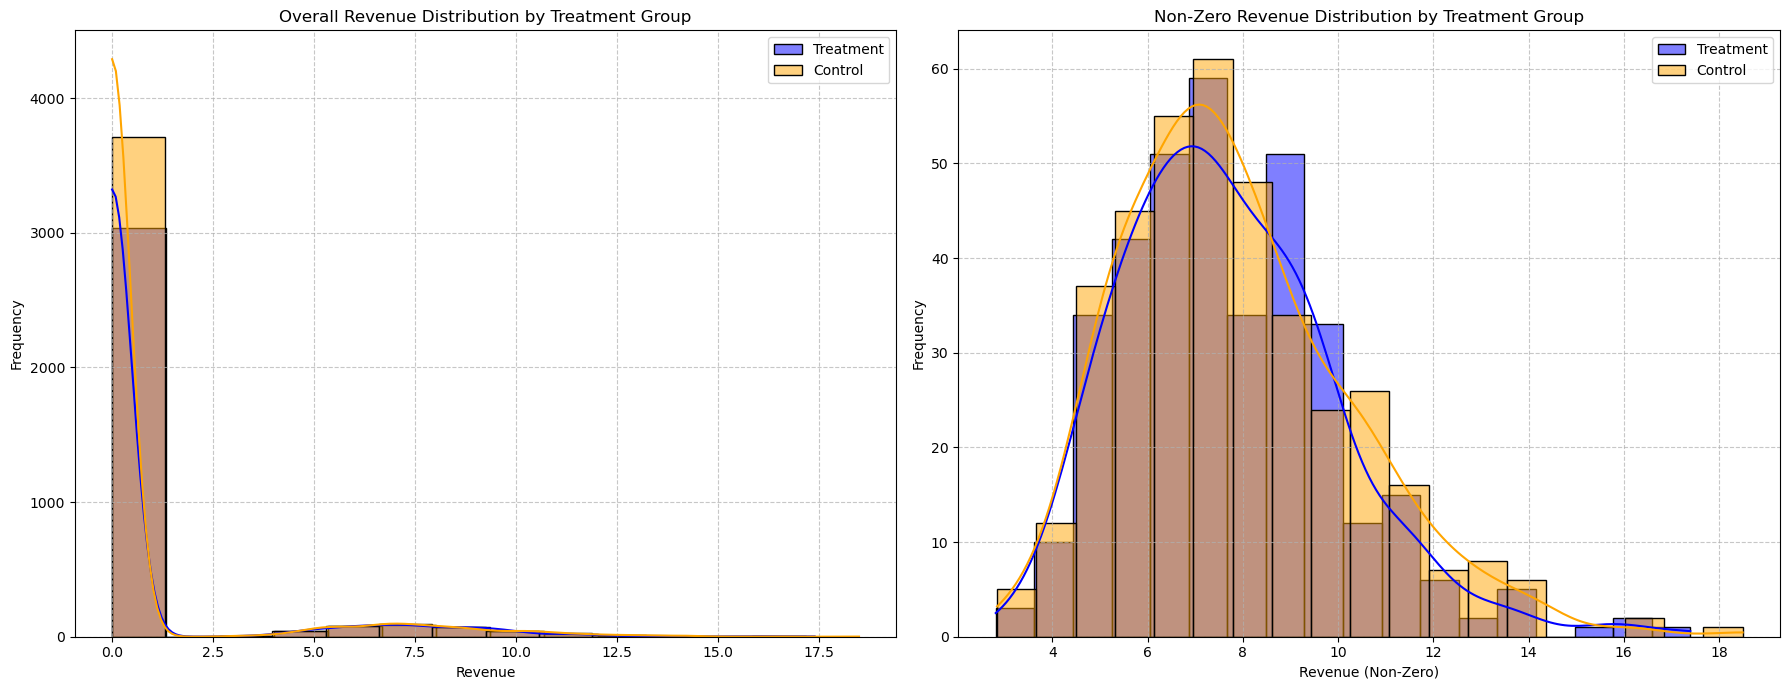

In [1062]:
plot_revenue_distributions(synthetic_df)

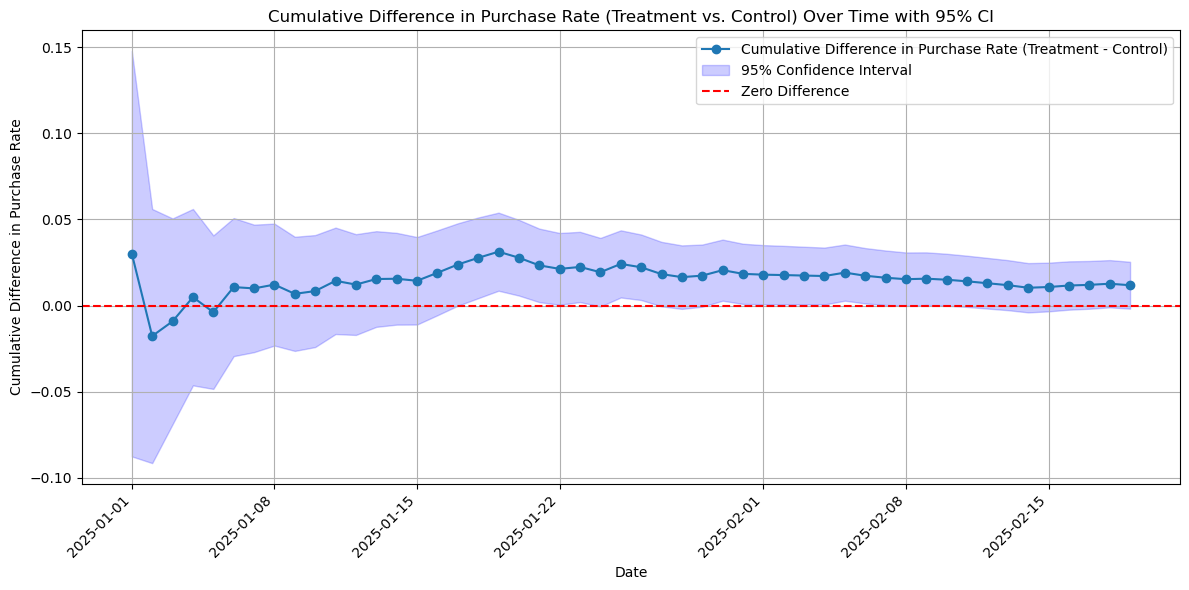

In [1063]:
cumulative_plot(synthetic_df, 'made_purchase', "Purchase Rate")

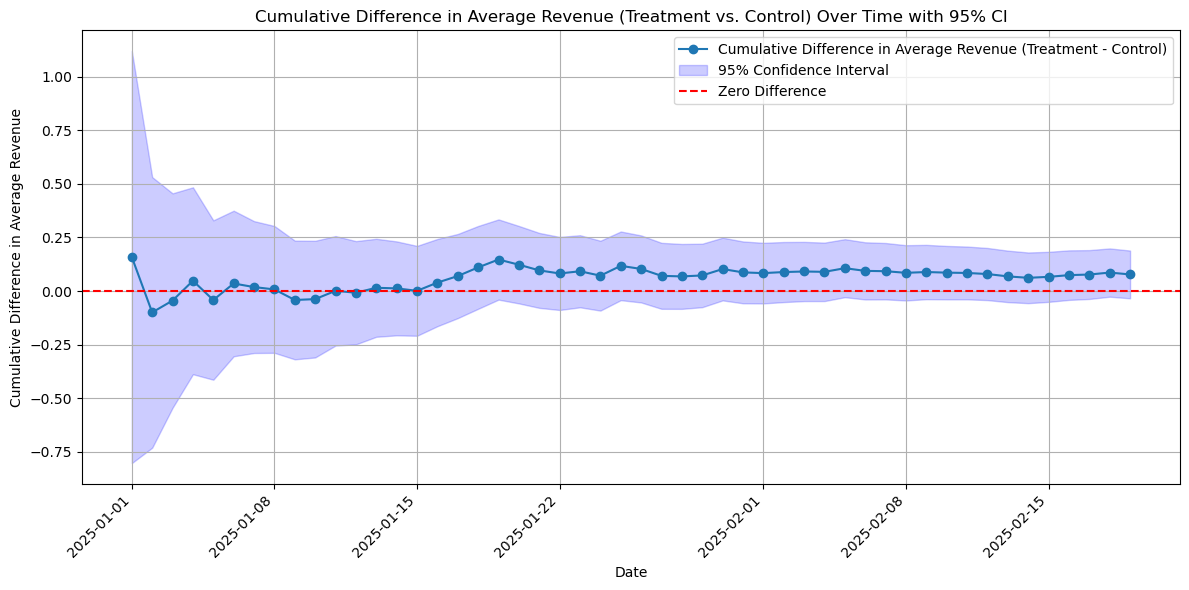

In [1064]:
cumulative_plot(synthetic_df, 'revenue', "Average Revenue")

In [1089]:
def calculate_cohens_d(group1, group2):
    """
    Calculates Cohen's d for the difference in means of two independent groups.
    This function is applicable to both continuous and binary (0/1) variables.

    Args:
        group1 (pd.Series): A pandas Series of numerical values for the first group.
        group2 (pd.Series): A pandas Series of numerical values for the second group.

    Returns:
        float: Cohen's d. Returns np.nan if calculation is not possible (e.g., zero variance
               within groups, insufficient data for pooled standard deviation).
    """
    mean1 = group1.mean()
    mean2 = group2.mean()
    n1 = len(group1)
    n2 = len(group2)

    # Handle cases with insufficient data for variance calculation (need at least 2 samples for ddof=1)
    if n1 < 2 or n2 < 2:
        return np.nan # Cannot calculate pooled std if one group has less than 2 samples

    var1 = group1.var(ddof=1) # Sample variance
    var2 = group2.var(ddof=1) # Sample variance

    # Denominator for pooled standard deviation
    # This also implicitly handles cases where n1+n2 < 3 (e.g., n1=1, n2=1)
    denominator_pooled_std = (n1 + n2 - 2)

    if denominator_pooled_std <= 0: # This means total samples are 2 or less.
                                   # We already handled n1<2 or n2<2, so this covers n1=1, n2=1
        return np.nan

    # Calculate pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / denominator_pooled_std)

    if pooled_std == 0:
        # This happens if all values within both groups are identical (e.g., all 0s or all 1s for binary)
        # In such a case, the standard deviation is 0, and Cohen's d is undefined.
        return np.nan

    d = (mean1 - mean2) / pooled_std
    return d

def calculate_relative_lift(group1, group2):
    mean1 = group1.mean()
    mean2 = group2.mean()
    n1 = len(group1)
    n2 = len(group2)

    relative_lift = ((mean1 - mean2) / mean2)*100
    return relative_lift

def calculate_cliffs_delta(group1, group2):
    """
    Calculates Cliff's delta for two independent groups.

    Args:
        group1 (np.ndarray or list): A numerical array or list for the first group.
        group2 (np.ndarray or list): A numerical array or list for the second group.

    Returns:
        float: Cliff's delta value.
    """
    group1 = np.asarray(group1)
    group2 = np.asarray(group2)

    n1 = len(group1)
    n2 = len(group2)

    if n1 == 0 or n2 == 0:
        return np.nan

    # Create a grid of all pairwise comparisons
    # This is a key step where broadcasting makes the calculation efficient.
    # The result is a 2D array where each element is a comparison result.
    comparisons = group1[:, None] > group2

    # Count the number of pairs where group1 > group2
    group1_gt_group2 = np.sum(comparisons)

    # Count the number of pairs where group2 > group1
    # We can do this by inverting the comparison result and subtracting the ties
    group2_gt_group1 = np.sum(group2[:, None] > group1)

    # Calculate Cliff's delta
    numerator = group1_gt_group2 - group2_gt_group1
    denominator = n1 * n2

    if denominator == 0:
        return np.nan

    delta = numerator / denominator
    return delta



In [1091]:
cohens_dict = {
    'var':'cohens_d',
    'metric':"Cohen's d",
    'method': calculate_cohens_d
}
relative_lift_dict = {
    'var':'relative_change',
    'metric':"Relative Lift (%)",
    'method': calculate_relative_lift
}
cliff_dict = {
    'var':'cliff_d',
    'metric':"Cliff's delta",
    'method': calculate_cliffs_delta
}

def effect_size_df(df, target, effect_var, method):
    cumulative_results = []
    unique_dates = df['date'].unique()
    df_sorted = df.sort_values('date')
    
    for current_date in unique_dates:
        cumulative_data = df_sorted[df_sorted['date'] <= current_date]
        treatment_cumulative = cumulative_data[cumulative_data['treatment'] == 'treatment'][target]
        control_cumulative = cumulative_data[cumulative_data['treatment'] == 'control'][target]
        results_cumulative = method(treatment_cumulative, control_cumulative)
        cumulative_results.append({'date': current_date, effect_var: results_cumulative})
    
    return pd.DataFrame(cumulative_results)

def plot_effect_size(metrics_dict, df, target_var, target_name):
    cumulative_effect_df = effect_size_df(df, target_var, metrics_dict['var'], metrics_dict['method'])

    plt.figure(figsize=(10, 6))
    plt.plot(cumulative_effect_df['date'], cumulative_effect_df[metrics_dict['var']], marker='o', linestyle='-')
    if metrics_dict['var']=='cohens_d':
        plt.axhline(y=0.2, color='black', linestyle='--', label="Small effect (0.2)")
        plt.axhline(y=0.5, color='red', linestyle='--', label="Medium effect (0.5)")
        plt.axhline(y=0.8, color='green', linestyle='--', label="Large effect (0.8)")
    else:
        plt.axhline(y=0, color='red', linestyle='--', label="No effect")
    plt.xlabel('Date')
    plt.ylabel(f"Cumulative {metrics_dict['metric']}")
    plt.title(f"Cumulative {metrics_dict['metric']} for {target_name}")
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

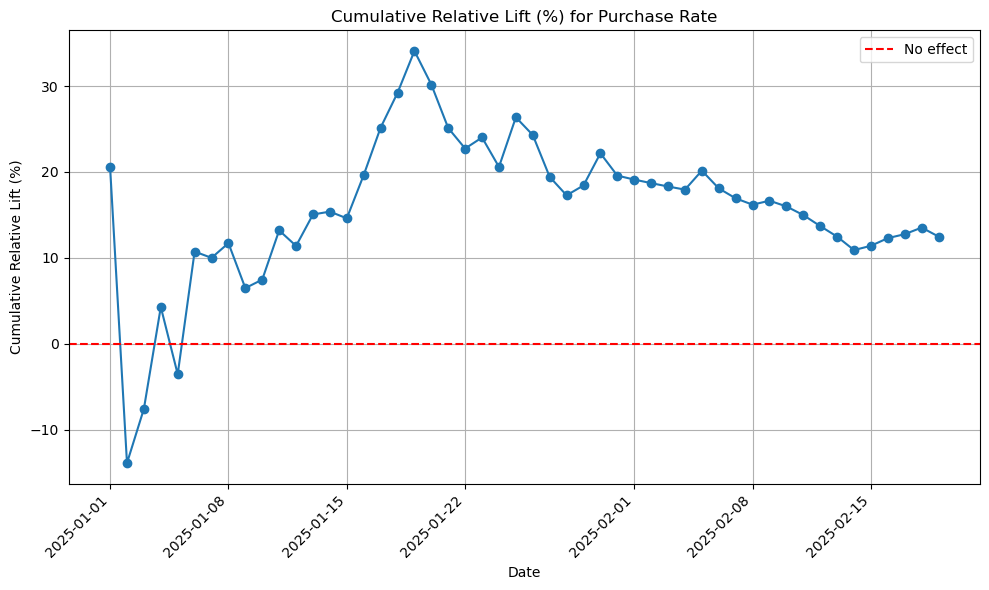

In [1067]:
plot_effect_size(relative_lift_dict, synthetic_df, 'made_purchase', 'Purchase Rate')

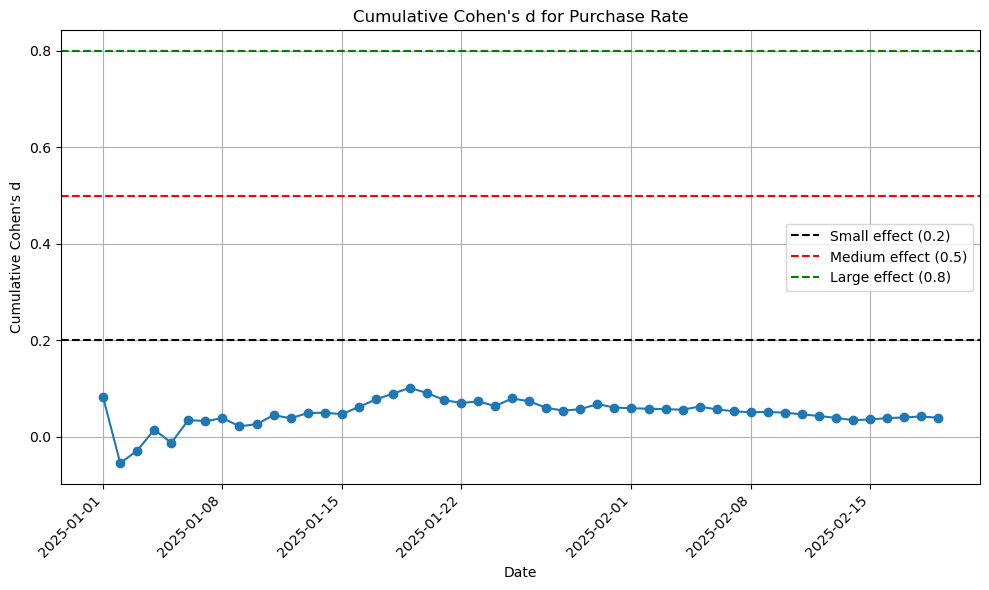

In [1068]:
plot_effect_size(cohens_dict, synthetic_df, 'made_purchase', 'Purchase Rate')

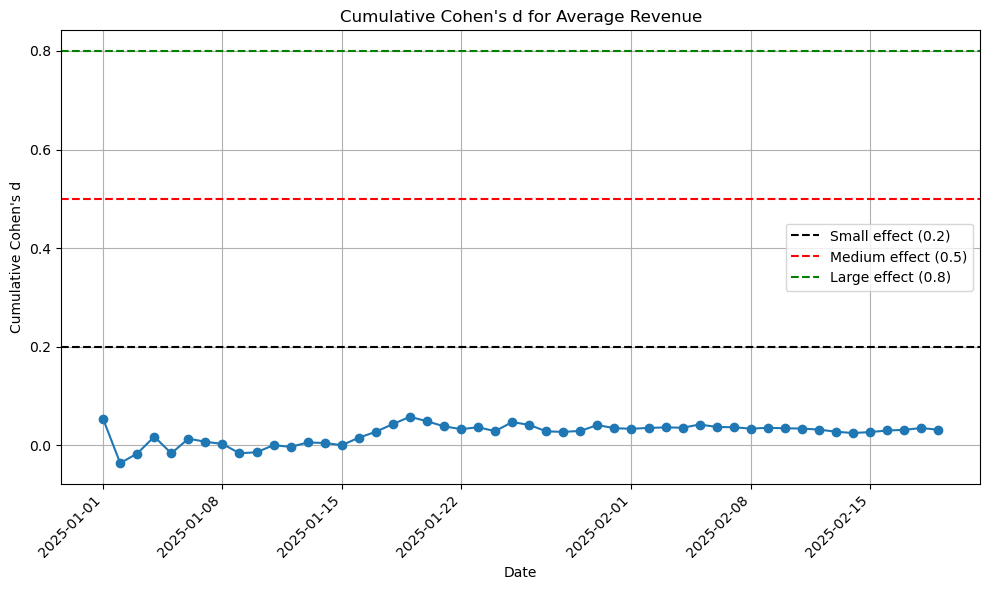

In [1069]:
plot_effect_size(cohens_dict, synthetic_df, 'revenue', 'Average Revenue')

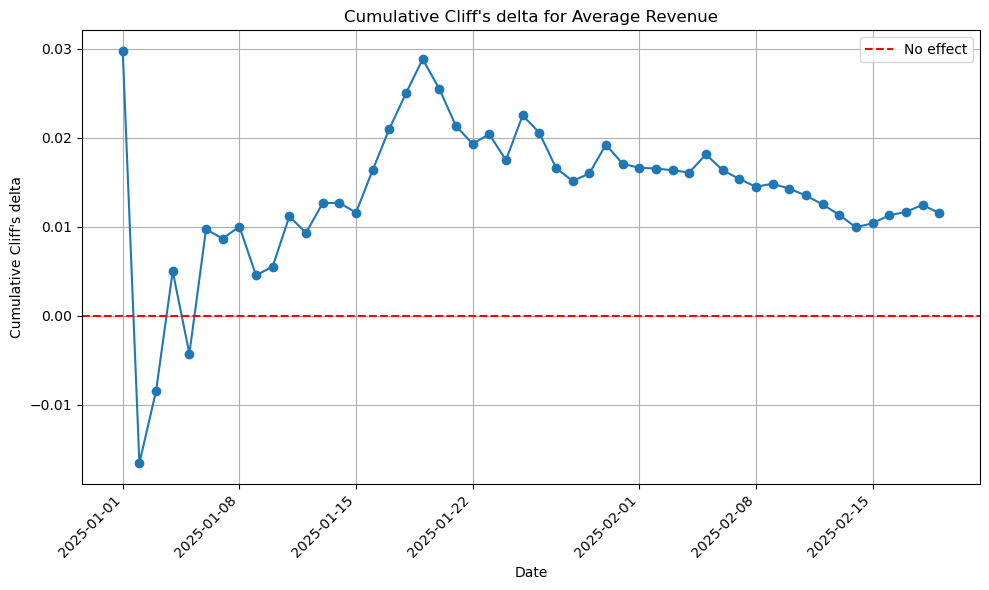

In [1093]:
plot_effect_size(cliff_dict, synthetic_df, 'revenue', 'Average Revenue')

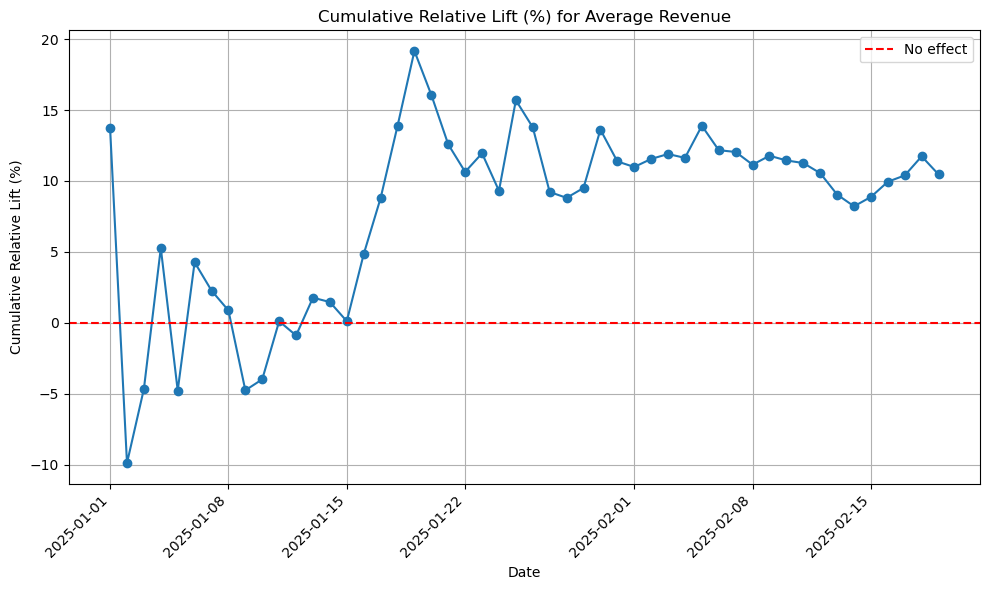

In [1070]:
plot_effect_size(relative_lift_dict, synthetic_df, 'revenue', 'Average Revenue')